In [660]:
# import ---------------------------------------
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 옵션 설정 --------------------------------
# 모든 컬럼 출력
pd.set_option('display.max_columns', None)
# 출력 너비 지정
pd.set_option('display.width', 1000)
# 배경 스타일 설정
sns.set_style('whitegrid')
# 한글 정렬 맞추기
pd.set_option('display.unicode.east_asian_width', True)
# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.tight_layout()
# 그래프 크기 설정
plt.figure(figsize=(15, 15))

# 파란계열
color = ['#003C97', '#004CBF', '#1460D2', '#1e75f5', '#69A6FF']
# 파란~청보라 계열
color2 = ['#174AD8', '#4153F0', '#0738D8', '#1e75f5', '#459BF2', '#1573D1']

color3 = [
    '#00cfd5', '#00b4d8', '#0096c7', '#0077b6', '#1e75f5',
    '#4361ee', '#4c27e1', '#5410c0', '#6305a3', '#82016f'
]
color4 = [
    '#0077b6', '#1e75f5','#5410c0', '#6305a3','#0096c7'
]
# csv 파일 읽어오기 -----------------------------
user = pd.read_csv('charangData/user.csv', encoding='cp949')
car = pd.read_csv('charangData/car.csv', encoding='cp949')
booking = pd.read_csv('charangData/booking.csv', encoding='cp949')
branch = pd.read_csv('charangData/branch.csv', encoding='cp949')

<Figure size 640x480 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>

### 1-a. **회원 나이별 예약 & 차종 분포**
#### - **그래프유형**: 원형그래프
#### - **기대효과**: 나이대별 예약점유를 파악하여 차량 신규 입고 시 고려
#### - **항목값**: 나이대(AgeGroup)
#### - **Raw Data**: user / booking

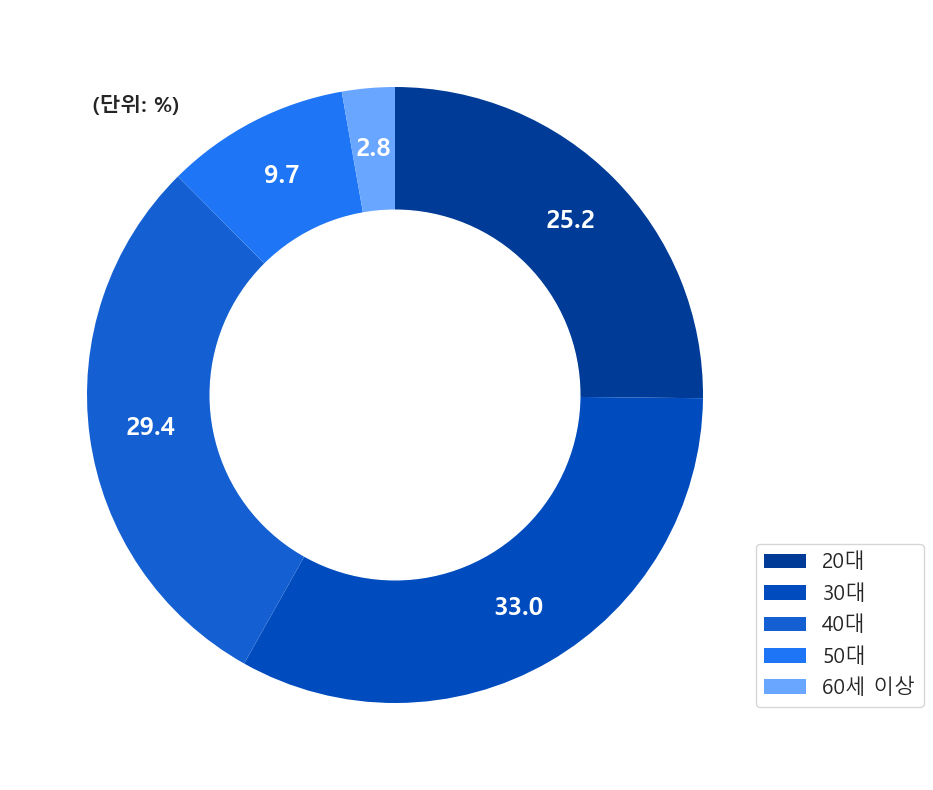

In [639]:
# 회원 나이별 예약 분포
# 결측치 주민등록번호에 대해서 평균값으로
# 전체 user 테이블의 resistNum의 
# 앞자리 두개를 이용해 나이 컬럼 생성 후 삽입
current_year = datetime.datetime.now().year

# 1. 앞 2자리 추출 및 숫자 변환
user['birth_year'] = pd.to_numeric(user['resistNum'].str[:2], errors='coerce')

# 2. 나이 판단 로직 (np.where 사용)
# 조건: 0~7 사이면 2000년대생, 아니면 1900년대생
user['age'] = np.where(
    user['birth_year'] <= 26,
    # 2026년 기준, 26 이하면 2000년대생
    current_year - (2000 + user['birth_year']),
    current_year - (1900 + user['birth_year'])
)
# 3. 나잇대별 그룹화
user['ageGroup'] = (user['age'] // 10).astype(int).astype(str) + '0대'
user.loc[user['age'] >= 60, 'ageGroup'] = '60세 이상'
user = user[user['ageGroup'] != '10대']  # 10대 값 2개 제거
# user['ageGroup'] = user['ageGroup'].replace('10대', '20대')

# 4. 데이터 병합 및 필요한 컬럼만 추출 + 결측치 처리(중간값)
merge01 = pd.merge(user, booking, how='outer', on='userId')
merge01['age'] = merge01['age'].fillna(merge01['age'].mean())
merge01a = merge01[['bookingId', 'ageGroup']]

merge01a
# 5. 나이별 예약 수 카운트
result = merge01a.groupby('ageGroup')['bookingId'].count()

# print(result)
# explod 설정
explode = [0.03] * len(result)
# 그래프 크기 설정
plt.figure(figsize=(10, 10))

# 원형그래프
table01 = plt.pie(
    result,
    # labels=result.index,
    labels=None,
    autopct='%1.1f',
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'none'},
    colors=color,
    pctdistance=0.8, 
    textprops={'fontsize':18, 'fontweight': 'bold'}
)
plt.text(-0.7, 0.92, "(단위: %)", fontsize=15, fontweight='bold', ha='right')

for per in table01[2]:
    per.set_color('#fff')

# 가운데 원
center_circle = plt.Circle((0, 0), 0.6, fc='white')
plt.gca().add_artist(center_circle)
# plt.title('나이별 예약 수', fontsize=18, fontweight='bold', color='#222', pad=20)

# 범례
plt.legend(
    labels=result.index,
    loc='upper right',
    bbox_to_anchor=(1.2, 0.32),
    fontsize=15,
    # color='#222'
    # ncol=2
)

# 그래프 이미지 저장
plt.savefig('그래프1', transparent=True, bbox_inches='tight')
plt.show()

### 1-b. **나이별 예약 차종 그래프**
#### - **그래프유형**: 누적 막대 그래프
#### - **기대효과**: 나이대별 예약수, 차종 분포를 파악하여 차량 신규 입고 시 고려
#### - **x축**: 나이대(AgeGroup)
#### - **x축**: 수(Count)
#### - **Raw Data**: user / booking / car

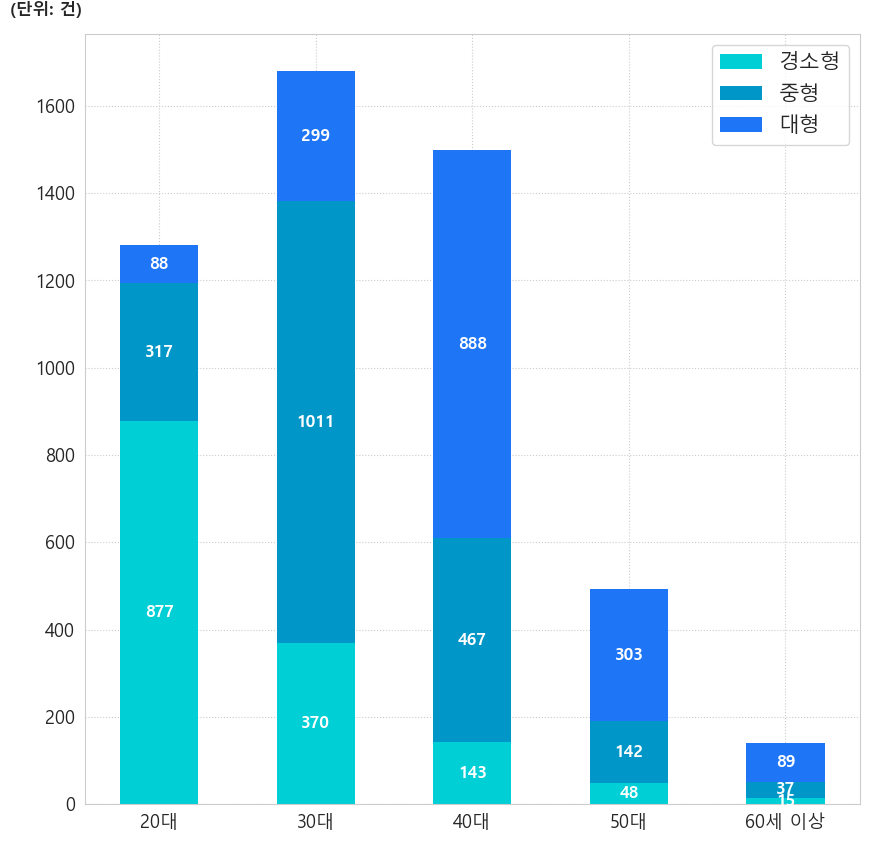

In [640]:
# 회원 나이별 차종 분포
# merge 후 필요한 데이터: carSize, ageGroup

# 데이터 병합 및 필요한 컬럼만 추출 + 결측치 처리(중간값으로)
merge02a = pd.merge(user, booking, how='inner', on='userId')
merge02a['age'] = merge02a['age'].fillna(merge02a['age'].median())
merge02b = pd.merge(merge02a, car, how='outer', on='carId')

# 차량 테이블 머지하기
merge02c = merge02b[['carSize', 'ageGroup']]
# merge02c
# 그룹화해서 개수 세기
grouped = merge02c.groupby(['ageGroup', 'carSize']).size()
# grouped

plt.figure(figsize=(10, 10))

# 세로로 된 데이터를 옆으로 펼치기
result02 = grouped.unstack()
x = result02.index

col1 = '경소형'
col2 = '중형'
col3 = '대형'

# 1. 그래프 그리기
plt.bar(x, result02[col1], label=col1, color=color3[0], width=0.5, edgecolor='none')
plt.bar(x, result02[col2], label=col2, bottom=result02[col1], color=color3[2], width=0.5, edgecolor='none')
plt.bar(x, result02[col3], label=col3, bottom=result02[col1] + result02[col2], color=color3[4], width=0.5, edgecolor='none')

# 2. 텍스트 라벨 추가
for i in range(len(result02)):
    # 데이터 값 가져오기
    val1 = result02[col1].iloc[i]
    val2 = result02[col2].iloc[i]
    val3 = result02[col3].iloc[i]

    # 첫 번째 막대(경소형) 중앙
    if val1 > 0: # 0인 경우 글씨 생략 가능
        plt.text(i, val1 / 2, int(val1), ha='center', va='center', fontweight='bold', color='white', fontsize=12)

    # 두 번째 막대(중형) 중앙: 경소형 높이 + (중형 높이 / 2)
    if val2 > 0:
        plt.text(i, val1 + (val2 / 2), int(val2), ha='center', va='center', fontweight='bold', color='white', fontsize=12)

    # 세 번째 막대(대형) 중앙: (경소형 + 중형 높이) + (대형 높이 / 2)
    if val3 > 0:
        plt.text(i, val1 + val2 + (val3 / 2), int(val3), ha='center', va='center', fontweight='bold', color='white', fontsize=12)

# 4. 그래프 디자인 및 가독성 향상
# plt.title('연령대별 차종 예약 분포', fontsize=18, fontweight='bold', color='#222', pad=20)
# plt.xlabel('연령대', fontweight='bold', fontsize=17, labelpad=20)
plt.ylabel(
    "(단위: 건)",
    fontweight='bold',
    fontsize=12,
    rotation=0,
)
plt.gca().yaxis.set_label_coords(-0.05, 1.02)
# 범례 생성
plt.legend(
    loc='upper right',
    bbox_to_anchor=(1, 1),
    fontsize=15,
    # ncol=3
)

plt.grid(axis='x', linestyle=':')
plt.grid(axis='y', linestyle=':')

plt.rc('xtick', labelsize=13), plt.rc('ytick', labelsize=13)

# 그래프 이미지 저장
plt.savefig("그래프2.png", dpi=300, transparent=True)
plt.show()


### 2. **월별 가입자수 추이**
#### - **그래프유형**: 꺾은선 그래프
#### - **기대효과**: 월별 가입차 추이를 통해 유입이 저조한 달의 경우, 대책 기획
#### - **X축**: 월(Month)
#### - **Y축**: 가입자수(Count)
#### - **Raw Data**: user

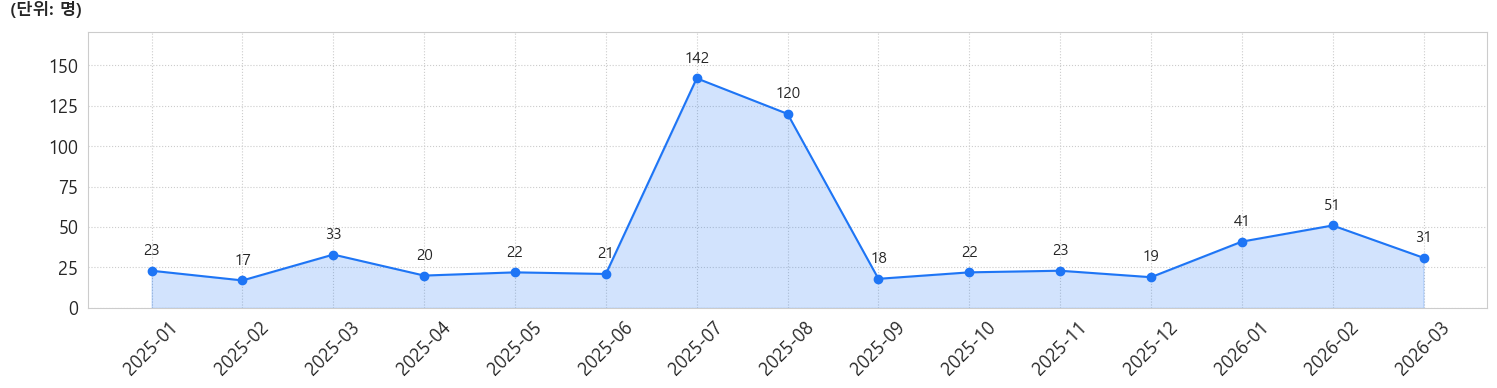

In [641]:
# 결측치 확인
# print(df02.isna().sum())

user['regDate'] = pd.to_datetime(user['regDate'])
user[['name', 'regDate']]

result = user.groupby(user['regDate'].dt.to_period('M')).size().reset_index(name = '가입자수')
result['regDate'] = result['regDate'].astype(str)  # period타입을 문자열로 변환

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 02. 그래프 크기 설정
plt.figure(figsize=(15,4))

# 03. 꺽은선 그래프
plt.plot(result['regDate'], result['가입자수'], marker='o', color='#1e75f5')

# 04. 영역 추가
plt.fill_between(result['regDate'], result['가입자수'], alpha=0.2, color='#1e75f5')

plt.grid(axis='x', linestyle=':')
plt.grid(axis='y', linestyle=':')

# 05. 제목, 라벨 지정
# plt.title('월별 가입자수 추이', fontsize=18, fontweight='bold', color='#222', pad=20)
# plt.xlabel('가입월', fontweight='bold', labelpad=20, fontsize=17)
plt.ylabel(
    "(단위: 명)",
    fontweight='bold',
    fontsize=12,
    rotation=0,
)
plt.gca().yaxis.set_label_coords(-0.03, 1.05)
plt.xticks(rotation=45)

# 수치 표시
for i, v in enumerate(result['가입자수']):
    plt.text(i, v + 10, int(v), ha='center', fontsize=11)

plt.rc('xtick', labelsize=13), plt.rc('ytick', labelsize=13)
plt.ylim(0, result['가입자수'].max() * 1.2)

plt.tight_layout()
plt.savefig("그래프3.png", dpi=300, transparent=True)
plt.show()

### 3-a. **월별 예약 횟수 **
#### - **그래프유형**: 꺾은선그래프
#### - **기대효과**: 월별 예약수 분석을 통한 요금 및 프로모션 전략 최적화
#### - **x축**: 년/월(Year/Month)
#### - **y축**: 예약수(Count)
#### - **Raw Data**: booking Table

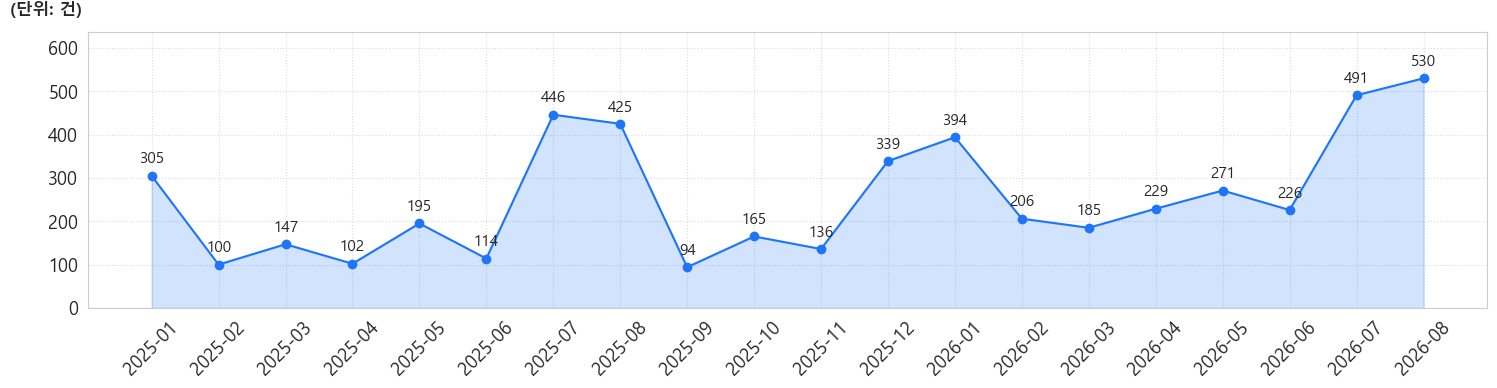

In [642]:
booking = pd.read_csv('charangData/booking.csv',encoding='cp949')

#예약날짜(결제일) 을 데이트타임으로 형변환
booking['startDate'] = pd.to_datetime(booking['startDate'])

#년/월 형식으로 str 가공
booking['년/월'] = booking['startDate'].dt.strftime('%Y-%m')
byMonth = booking.groupby('년/월').size().reset_index(name='예약수')

plt.figure(figsize=(15,4))

bars = plt.plot(byMonth["년/월"],byMonth["예약수"], marker ='o', color='#1e75f5')
plt.fill_between(byMonth['년/월'],byMonth['예약수'], alpha=0.2, color='#1e75f5')

plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.grid(axis='y', linestyle=':', alpha=0.7)

# plt.title("월별 예약 횟수", fontsize=18, fontweight='bold', color='#222', pad=20)
# plt.xlabel("예약월", fontweight='bold', labelpad=20)
# plt.ylabel("예약수", fontweight='bold', )
plt.ylabel(
    "(단위: 건)",
    fontweight='bold',
    fontsize=12,
    rotation=0,
)
plt.gca().yaxis.set_label_coords(-0.03, 1.05)
plt.xticks(rotation=45)

# 수치 표시
for i, v in enumerate(byMonth["예약수"]):
    plt.text(i, v + 20, int(v), 
             ha='center', 
             va='bottom',  # 점의 위쪽을 기준으로 정렬
             fontsize=11,
    )

plt.rc('xtick', labelsize=13), plt.rc('ytick', labelsize=13)
plt.ylim(0, byMonth["예약수"].max() * 1.2)

plt.tight_layout()
plt.savefig("그래프5.png", dpi=300, transparent=True)
plt.show()

### 3-b. **월별 매출 추이 **
#### - **그래프유형**: 꺾은선그래프
#### - **기대효과**: 월별 예약 매출 분석을 통한 요금 및 프로모션 전략 최적화
#### - **x축**: 년/월(Year/Month))
#### - **y축**: 매출(Price)
#### - **Raw Data**: booking Table

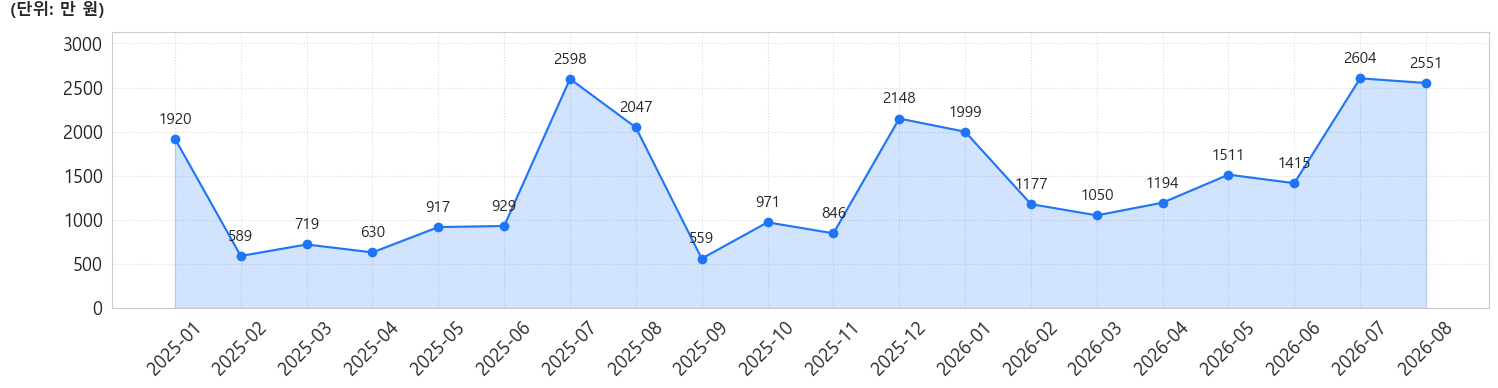

In [643]:
booking = pd.read_csv('charangData/booking.csv',encoding='cp949')

#예약날짜(결제일) 을 데이트타임으로 형변환
booking['bookedDate'] = pd.to_datetime(booking['bookedDate'])


#년/월 형식으로 str 가공
booking['년/월'] = booking['bookedDate'].dt.strftime('%Y-%m')
byMonth = booking.groupby('년/월')['totalPrice'].sum().reset_index()
byMonth['totalPrice'] = byMonth['totalPrice'] / 10000 
# 반드시 한글 깨짐 현상 코드를 삽입한다.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(15,4))

bars = plt.plot(byMonth["년/월"],byMonth["totalPrice"],marker ='o', color='#1e75f5')
plt.fill_between(byMonth['년/월'],byMonth['totalPrice'], alpha=0.2, color='#1e75f5')

plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.grid(axis='y', linestyle=':', alpha=0.7)

# plt.title("월별 매출", fontsize=18, fontweight='bold', color='#222', pad=20)
# plt.xlabel("예약월", fontweight='bold', labelpad=20)
plt.ylabel(
    "(단위: 만 원)",
    fontweight='bold',
    fontsize=12,
    rotation=0,
)
plt.gca().yaxis.set_label_coords(-0.04, 1.05)
plt.xticks(rotation=45)

# 수치 표시
for i, v in enumerate(byMonth['totalPrice']):
    plt.text(i, v + 130, int(v), 
             ha='center', 
             va='bottom',  # 점의 위쪽을 기준으로 정렬
             fontsize=11,
    )

plt.rc('xtick', labelsize=13), plt.rc('ytick', labelsize=13)
plt.ylim(0, byMonth['totalPrice'].max() * 1.2)

plt.tight_layout()
plt.savefig("그래프4.png", dpi=300, transparent=True)
plt.show()

### 4. **시간대별 차량이용 횟수**
#### - **그래프영문명**: hourly_usage_count
#### - **그래프유형**: 막대 그래프
#### - **기대효과**: 피크타임 시간대 대책 기획 / 장기, 단기 렌트에 대한 기획
#### - **x축**: 시간(Hour)
#### - **x축**: 수(Count)
#### - **Raw Data**: booking

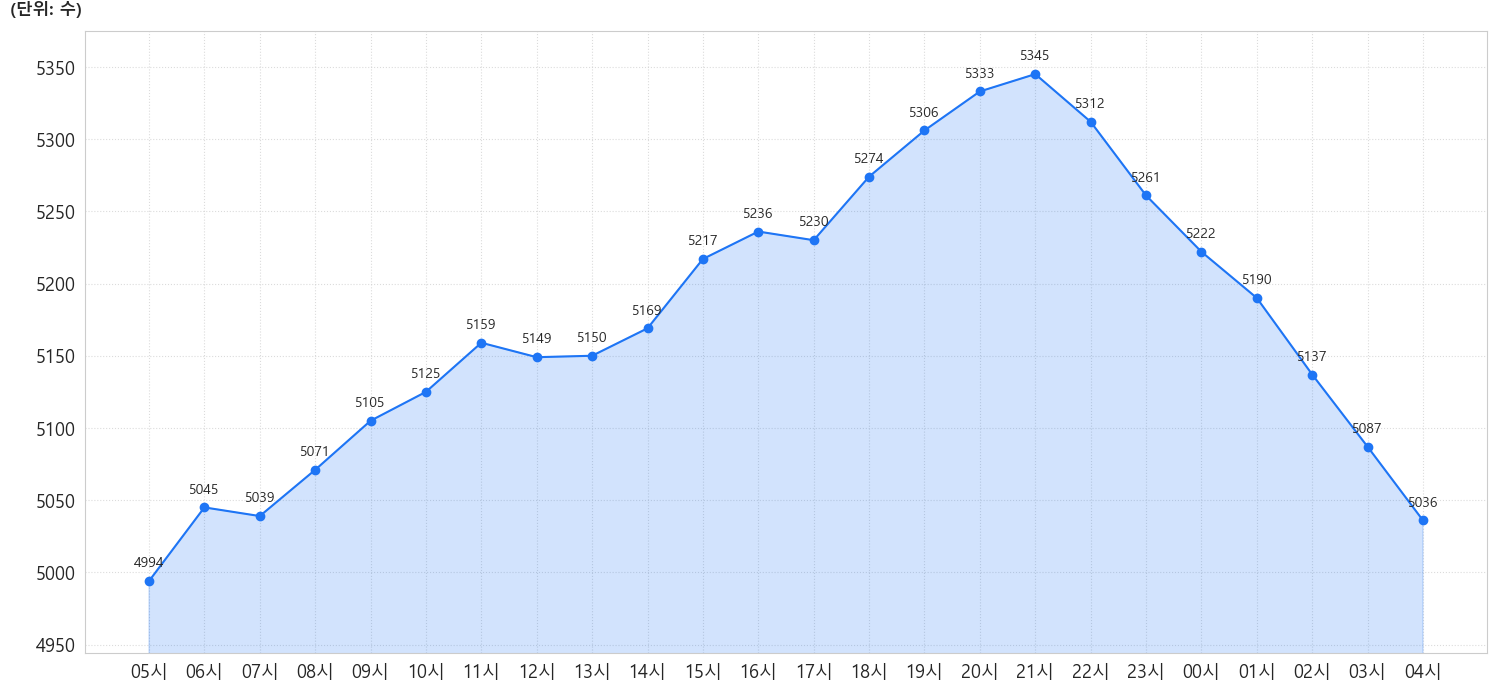

In [651]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 예약 시작/종료 시간을 datetime 객체로 변환
start_full = pd.to_datetime(booking['startDate'] + ' ' + booking['startTime'])
end_full = pd.to_datetime(booking['endDate'] + ' ' + booking['endTime'])

# 2. 0~23시 빈도를 저장할 배열 초기화
hourly_counts = np.zeros(24)

# 3. 각 예약 건별로 포함된 모든 시간대를 1씩 증가
for start, end in zip(start_full, end_full):
    hours = pd.date_range(start=start.floor('h'), end=end.floor('h'), freq='h')
    for h in hours.hour:
        hourly_counts[h] += 1

# 4. 사용자 정의 순서 (5시 ~ 익일 4시)로 데이터 재배열
custom_order = list(range(5, 24)) + list(range(0, 5))
ordered_counts = [hourly_counts[h] for h in custom_order]

# 그래프 출력
x_labels = [f"{h:02d}시" for h in custom_order]

x_axis = np.arange(len(x_labels))

plt.figure(figsize=(15, 7))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 꺾은선 그래프
plt.plot(
    x_axis, 
    ordered_counts, 
    marker='o', 
    label='이용 차량 수', 
    color='#1e75f5'
)

# 선 아래 영역 채우기 (2100을 기준으로 채움)
plt.fill_between(x_axis, ordered_counts, 2100, alpha=0.2, color='#1e75f5')

# y축 범위 설정 (변화를 극대화)
plt.ylim(min(ordered_counts) - 50, max(ordered_counts) + 30) 

plt.xticks(x_axis, x_labels)
# plt.title('시간대별 차량 이용 변화 추이', fontsize=18, fontweight='bold', color='#222', pad=20)
# plt.xlabel('시간 (5시 ~ 익일 4시)', fontweight='bold')
plt.ylabel(
    "(단위: 수)",
    fontweight='bold',
    fontsize=12,
    rotation=0,
)
plt.gca().yaxis.set_label_coords(-0.028, 1.02)

plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.grid(axis='y', linestyle=':', alpha=0.7)
# plt.xticks(rotation=45)
# 수치 표시
for i, v in enumerate(ordered_counts):
    plt.text(i, v + 10, int(v), ha='center')

plt.tight_layout()
plt.savefig("그래프7.png", dpi=300, transparent=True)
plt.show()

### 5. **대여(이용)시간 별 예약수**
#### - **그래프유형**: 꺾은선그래프
#### - **기대효과**: 이용 시간 길이 분석을 통한 요금 및 프로모션 전략 최적화
#### - **x축**: 대여(이용)시간(Time)
#### - **y축**: 예약수(Count)
#### - **Raw Data**: booking Table

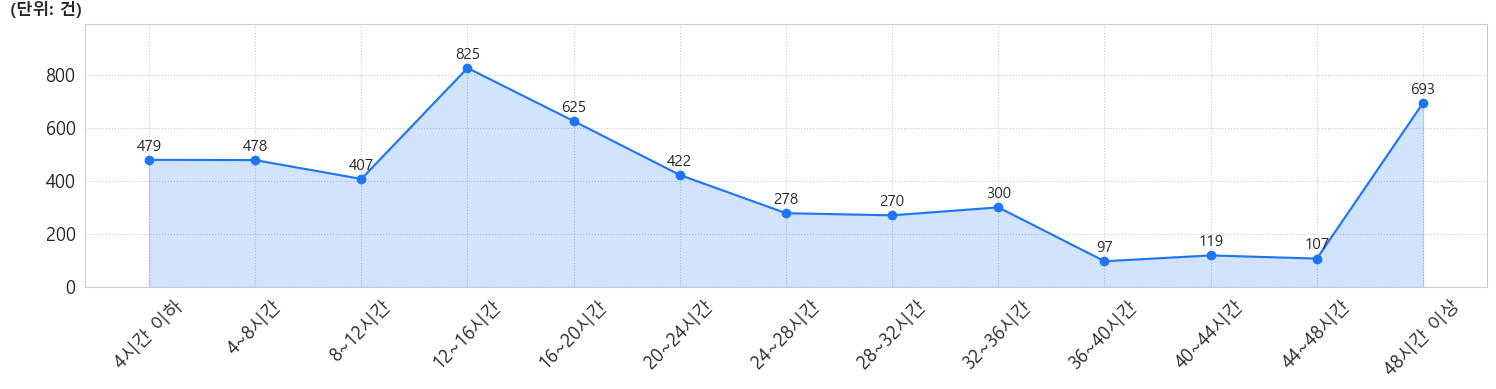

In [646]:
# 대여(이용) 시간 별 예약수를 뽑아내야하므로 booking.csv
booking = pd.read_csv('charangData/booking.csv',encoding='cp949')
bins = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36,40,44,48,float('inf')]
#bins = [0, 6, 12, 18, 24, 30, 36, 42, 48, 54,60,66,float('inf')]
labels = [
    "4시간 이하", "4~8시간", "8~12시간", "12~16시간",
    "16~20시간", "20~24시간", "24~28시간", "28~32시간",
    "32~36시간", "36~40시간","40~44시간", "44~48시간", "48시간 이상"
]

# 차량 반납시간과 시작시간을  년-월-일-시-분 형태로 가공하여 새로운 필드로 추가
booking['대여시작'] = pd.to_datetime(booking['startDate'] + ' ' + booking['startTime'])
booking['차량반납'] = pd.to_datetime(booking['endDate'] + ' ' + booking['endTime'])

# 차량 반납시간 - 대여시작시간해서 초로하고 시로 나눠서 n시간 형식으로 출력
booking['대여(이용)시간'] = (pd.to_datetime(booking['차량반납']) - pd.to_datetime(booking['대여시작'])).dt.total_seconds() / 3600
# 구간마다 대여(이용)시간을  bin 기준으로 값 비교하여 분할 
booking['대여(이용)시간'] = pd.cut(booking['대여(이용)시간'], bins=bins, labels=labels, right=False   # 0,3 이런식 (3은 다음구간)
)

result = booking['대여(이용)시간'].value_counts().sort_index()
byTime = booking.groupby('대여(이용)시간',observed=False).size().reset_index(name='예약수')

# 반드시 한글 깨짐 현상 코드를 삽입
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(15,4))

bars = plt.plot(byTime['대여(이용)시간'],byTime["예약수"],marker ='o', color='#1e75f5')
plt.fill_between(byTime['대여(이용)시간'],byTime['예약수'], alpha=0.2, color='#1e75f5')
plt.xticks(rotation=45)

plt.grid(axis='x', linestyle=':')
plt.grid(axis='y', linestyle=':')

# plt.title("대여(이용) 시간 별 예약건수", fontsize=18, fontweight='bold', color='#222', pad=20)
plt.ylabel(
    "(단위: 건)",
    fontweight='bold',
    fontsize=12,
    rotation=0,
)
# 수치 표시
for i, v in enumerate(byTime['예약수']):
    plt.text(i, v + 20, int(v), 
             ha='center', 
             va='bottom',  # 점의 위쪽을 기준으로 정렬
             fontsize=11,
    )

plt.rc('xtick', labelsize=13), plt.rc('ytick', labelsize=13)
plt.gca().yaxis.set_label_coords(-0.028, 1.02)

plt.tight_layout()
plt.ylim(0, byTime['예약수'].max() * 1.2)
plt.savefig("그래프6.png", dpi=300, transparent=True)
plt.show()

### 6. **브랜드별 예약 횟수** (brand_reserve_count)
#### - **그래프유형**: 원형그래프
#### - **기대효과**: 추후 들여올 차량 브랜드 선정시 유효
#### - **항목값**: 수(Count)
#### - **Raw Data**: booking Table / car Table

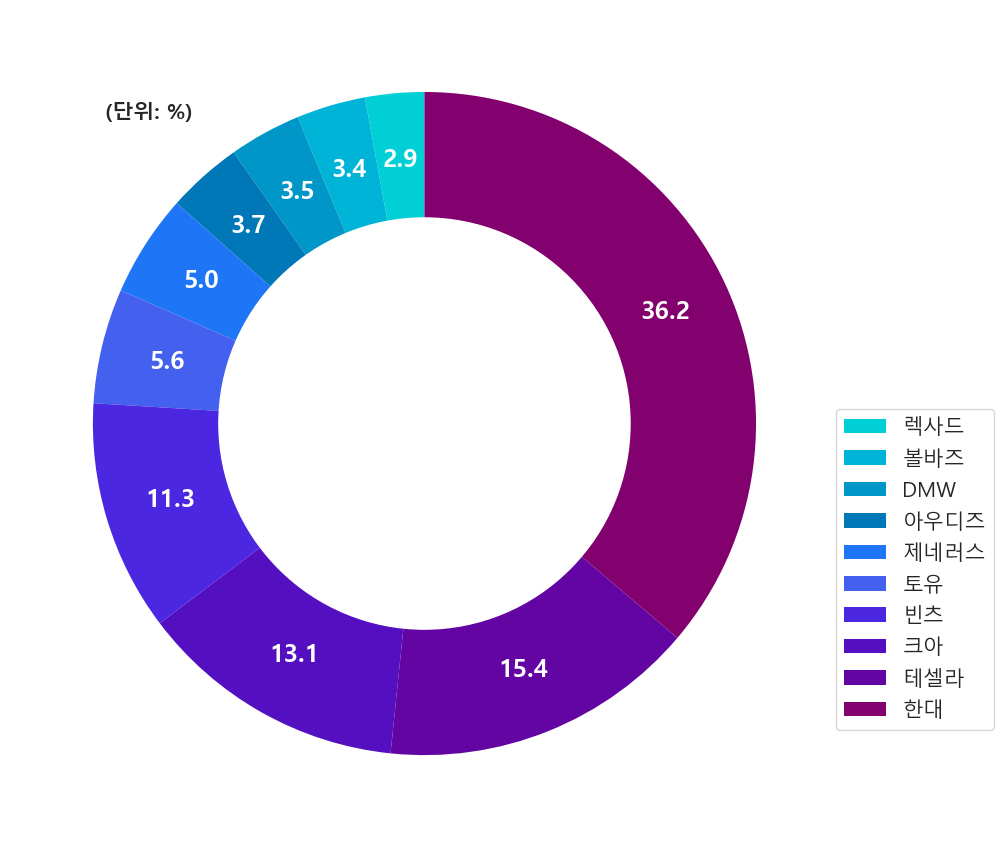

In [650]:
# merge - booking, car
merge06 = pd.merge(booking, car, how='outer', on='carId')
merge06

mer06Cnt = merge06.groupby('brand').size().sort_values(ascending=False).head(10).sort_values(ascending=True)

# print(mer06Cnt)

plt.figure(figsize=(10,10))

plt.text(-0.7, 0.92, "(단위: %)", fontsize=15, fontweight='600', ha='right')

# plt.pie(mer06Cnt, labels=mer06Cnt.index, autopct='%1.1f%%', startangle=90)
table06 = plt.pie(
    mer06Cnt, 
    # labels=mer06Cnt.index,
    autopct='%1.1f', 
    startangle=90,
    # colors=['#1e75f5', '#0552c6', '#2b7cf7', '#6ca4f8'],
    wedgeprops={'edgecolor': 'none'},
    # explode=[0.07] * len(mer06Cnt),
    colors=color3,
    pctdistance=0.8,  # 퍼센트 글자 위치 (0~1 사이)
    textprops={
        'fontsize':18,
        'fontweight': 'bold',
   })

for label in table06[1]:
    label.set_color('#222')
for per in table06[2]:
    per.set_color('#fff')

# 가운데 원
center_circle = plt.Circle((0, 0), 0.62, fc='white')
plt.gca().add_artist(center_circle)
# 범례
plt.legend(
    labels=mer06Cnt.index,
    loc='upper right',
    bbox_to_anchor=(1.2, 0.53),
    fontsize=15,
)
# cir = plt.Circle((0,0), 0.3, fc='white')
# plt.gca().add_artist(cir)

# plt.title('브랜드별 예약 횟수 (Top 10)', fontsize=18, fontweight='bold', color='#222', pad=20)
plt.tight_layout()
plt.savefig('그래프8', transparent=True)  # 투명화 저장

plt.show()

### .7 **차종별(연료타입분리x) 예약 횟수**
#### - **그래프유형**: 막대사탕 차트
#### - **기대효과**: 인기 차량 확인가능. 들여올 차량 선정시 유효
#### - **X축**: 수(Count)
#### - **Raw Data**: booking / car

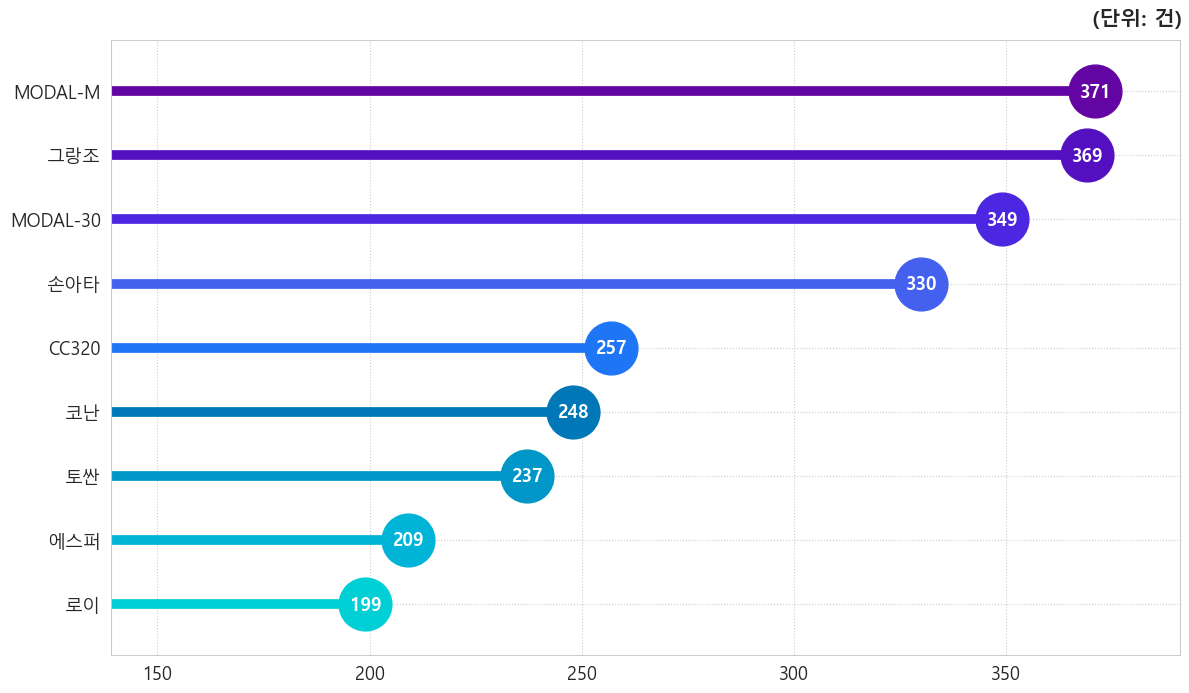

In [648]:
import pandas as pd
import matplotlib.pyplot as plt

merge07 = pd.merge(booking, car, how='outer', on='carId')
# 오름차순으로 정렬해서 그래프 밑에서부터 위로 올라가게 준비 (Lollipop용)
result = (merge07.groupby('model')
          .size()
          .sort_values(ascending=False)
          .head(9)
          .reset_index(name='예약건수')
          .sort_values('예약건수', ascending=True))

# 02. 그래프 크기 설정 및 스타일
fig, ax = plt.subplots(figsize=(12, 7))

for i, (model, count) in enumerate(zip(result['model'], result['예약건수'])):
    # 각 순서(i)에 맞는 색상 선택
    current_color = color3[i] 
    # 줄기 그리기
    ax.hlines(y=model, xmin=0, xmax=count, color=current_color, linewidth=7)
    # 사탕 그리기
    ax.plot(count, model, 'o', 
            markersize=38, 
            markeredgecolor=current_color, 
            markerfacecolor=current_color)
# 03. 디테일 설정 
plt.xlabel('(단위: 건)', fontweight='bold')

# y축(모델명) 라벨 제거 (어차피 축에 써있음)
# plt.ylabel('모델명', fontweight='bold')

plt.grid(axis='x', linestyle=':')
plt.grid(axis='y', linestyle=':')

# 04. 막대 끝에 숫자 표시 
for i, txt in enumerate(result['예약건수']):
    target_pos = (result['예약건수'].iloc[i], result['model'].iloc[i])
    
    ax.annotate(txt, 
                xy=target_pos,  # 기준점
                xytext=(0.5, -0.5),  # 좌표 지정
                textcoords='offset points',
                ha='center', va='center',  # 중앙 정렬 베이스
                fontsize=13, color='white', fontweight='bold')

plt.xlim(min(result['예약건수']) - 60, max(result['예약건수']) + 20)
plt.ylim(-0.8, len(result) - 0.2)
plt.gca().xaxis.set_label_coords(0.96, 1.05)
plt.tight_layout()
plt.savefig('그래프9', transparent=True)  # 투명화 저장
plt.show()

### 8. **지점별 예약수** (branch_reserve_count)
#### - **그래프유형**: 누적 막대그래프
#### - **기대효과**: 지점별 인기차량? 회원선호도 확인? 가능?
#### - **X축**: 년/월
#### - **Y축**: 지점별 누적 예약수
#### - **Raw Data**: branch Table / car Table / user Table / booking Table

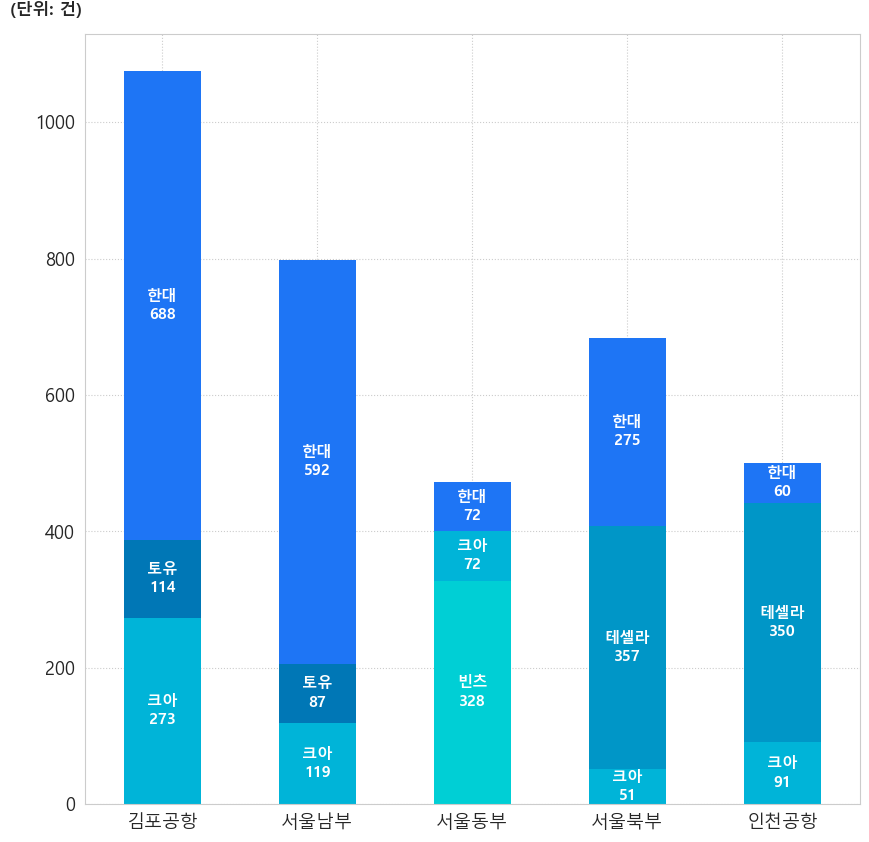

In [663]:
# 1. merge - branch, car
merge08_BranchCar = pd.merge(branch, car, how='outer', on='branchId')
# 2. merge - user, booking
merge08_UserBook = pd.merge(user, booking, how='outer', on='userId')

# 3. merge - merge08_BranchCar, merge08_UserBook
merge08 = pd.merge(merge08_UserBook, merge08_BranchCar, how='inner', on='carId')

# 데이터 집계
counts = merge08.groupby(['location', 'brand']).size().reset_index(name='cnt')
top3 = counts.sort_values(['location', 'cnt'], ascending=[True, False]).groupby('location').head(3)

# 그래프 그리기용 피벗 테이블
table = top3.pivot(index='location', columns='brand', values='cnt').fillna(0)

# 그래프 출력
ax = table.plot(kind='bar', stacked=True, legend=False, color=color3, figsize=(10, 10), edgecolor='none')

# 항목별 이름(brand)과 수치 표시
for c in ax.containers:
    brand = c.get_label()  # 브랜드 이름 가져오기
    labels = [f'{brand}\n{int(v)}' if v > 0 else '' for v in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=11, fontweight='bold', color='#fff')

#  plt.title('지점별 인기 브랜드 Top 3', fontsize=18, fontweight='bold', color='#222', pad=20)
plt.xlabel('')
plt.ylabel(
    "(단위: 건)",
    fontweight='bold',
    fontsize=12,
    rotation=0,
)
plt.gca().yaxis.set_label_coords(-0.05, 1.02)

plt.grid(axis='x', linestyle=':')
plt.grid(axis='y', linestyle=':')

plt.xticks(rotation=0)

plt.savefig('그래프10', transparent=True)  # 투명화 저장
plt.show()